In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

import tensorflow as tf

2024-05-04 22:05:26.655558: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-04 22:05:26.655620: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-04 22:05:26.702316: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-05-04 22:05:26.793602: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-04 22:05:28.035759: W tensorflow/compiler/tf2

# Preprocessing

## Read Data


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')
# import os

# GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'CS539_ANN/final_project'
# GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
# print(os.listdir(GOOGLE_DRIVE_PATH))

# PATH = os.path.join(GOOGLE_DRIVE_PATH, 'archive/asl_alphabet_train/asl_alphabet_train') # why is the folder structure like this idk
BATCH_SIZE = 32
IMG_SIZE = (160, 160)

# dataset = tf.keras.utils.image_dataset_from_directory(PATH, shuffle = True, batch_size = BATCH_SIZE, image_size = IMG_SIZE)

dataset = tf.keras.utils.image_dataset_from_directory('archive/asl_alphabet_train/asl_alphabet_train', shuffle = True, batch_size = 32, image_size = (160, 160))

class_names = dataset.class_names
num_classes = len(class_names)

Found 87000 files belonging to 29 classes.


In [3]:
# Get the total number of batches in the dataset
total_batches = tf.data.experimental.cardinality(dataset).numpy()

# Calculate the number of batches for each split
val_batches = total_batches // 5  # 20% for validation
test_batches = total_batches // 5  # 20% for testing
train_batches = total_batches - val_batches - test_batches  # 60% for training

# # Way too much data
# val_batches = 5
# test_batches = 5
# train_batches = 20

# Split the dataset into train, validation, and test datasets
train_dataset = dataset.take(train_batches)
remaining_dataset = dataset.skip(train_batches)

validation_dataset = remaining_dataset.take(val_batches)
test_dataset = remaining_dataset.skip(val_batches).take(test_batches)

print('Number of train batches: %d' % tf.data.experimental.cardinality(train_dataset))
print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_dataset))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_dataset))

Number of train batches: 1633
Number of validation batches: 543
Number of test batches: 543


## Performance Configurations

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

## Data Augmentation and Pixel Normalization

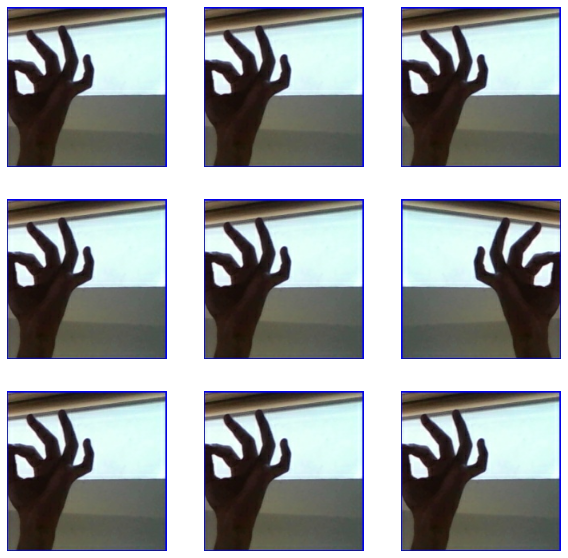

In [5]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
])

for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')


# Base Model

## Feature Extraction

In [6]:
preprocess_input = tf.keras.applications.efficientnet.preprocess_input


# Base Model
base_model = tf.keras.applications.EfficientNetB0(input_shape=((IMG_SIZE) + (3,)),
                                               include_top=False,
                                               weights='imagenet')


image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

base_model.summary()


(32, 5, 5, 1280)
Model: "efficientnetb0"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 160, 160, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 160, 160, 3)          0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 160, 160, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)     (None, 160, 160, 3)          0         

### Freeze Base Model

In [7]:
base_model.trainable = False

### Add Classification Head

In [8]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)

prediction_layer = tf.keras.layers.Dense(num_classes, activation="sigmoid")

prediction_batch = prediction_layer(feature_batch_average)

inputs = tf.keras.Input(shape=(160, 160, 3))

x = data_augmentation(inputs)

x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)

outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 160, 160, 3)       0         
                                                                 
 efficientnetb0 (Functional  (None, 5, 5, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 29)                37149     
                                                                 
Total params: 4086720 (15.59 MB)
Trainable params: 37149 (145

### Compile Model

In [ ]:
base_learning_rate = 0.00001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

### Train Model

In [ ]:
initial_epochs = 3

loss0, accuracy0 = model.evaluate(validation_dataset)
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

5/5 [==============================] - 2s 275ms/step - loss: 3.1052 - accuracy: 0.1562
Epoch 1/3
20/20 [==============================] - 7s 350ms/step - loss: 3.0248 - accuracy: 0.2031 - val_loss: 3.0624 - val_accuracy: 0.1937
Epoch 2/3
20/20 [==============================] - 6s 302ms/step - loss: 2.9130 - accuracy: 0.2766 - val_loss: 3.0241 - val_accuracy: 0.1937
Epoch 3/3
20/20 [==============================] - 6s 308ms/step - loss: 2.8368 - accuracy: 0.3094 - val_loss: 2.9370 - val_accuracy: 0.2688


### Performance Metrics

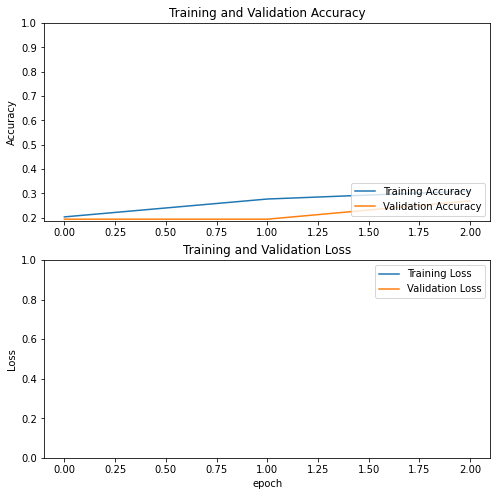

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Loss')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()



# Fine Tune

## Unfreeze Base Model

In [ ]:
start = len(base_model.layers) - 3
print(start)

for layer in model.layers[:start]:
   layer.trainable = False
for layer in model.layers[start:]:
   layer.trainable = True

235


## Recompile Model

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate/100),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

## Fine Tune Training

In [ ]:
fine_tune_epochs = 3
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1],
                         validation_data=validation_dataset)

acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

Epoch 3/6


20/20 [==============================] - 11s 373ms/step - loss: 2.7961 - accuracy: 0.3359 - val_loss: 2.9130 - val_accuracy: 0.2562
Epoch 4/6
20/20 [==============================] - 7s 332ms/step - loss: 2.8012 - accuracy: 0.3234 - val_loss: 2.8817 - val_accuracy: 0.2875
Epoch 5/6
20/20 [==============================] - 7s 347ms/step - loss: 2.7682 - accuracy: 0.3656 - val_loss: 2.9139 - val_accuracy: 0.2937
Epoch 6/6
20/20 [==============================] - 7s 326ms/step - loss: 2.7773 - accuracy: 0.3359 - val_loss: 2.8851 - val_accuracy: 0.3063


## Performance Metrics

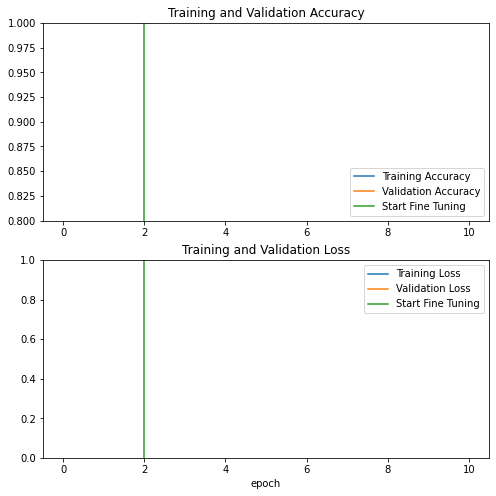

5/5 [==============================] - 2s 222ms/step - loss: 2.8688 - accuracy: 0.2812
Test accuracy : 0.28125


In [ ]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

In [ ]:
# model.save('EfficientNetB0_4-27_940PM.keras')

In [ ]:
loaded_model = tf.keras.saving.load_model('EfficientNetB0_4-27_940PM.keras')
model = loaded_model

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import itertools

# Get the predictions for the test dataset
y_pred = []
y_true = []

for x, y in test_dataset:
    y_pred.extend(model.predict(x))
    y_true.extend(y.numpy())

# Convert the predictions and true labels to NumPy arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Convert the predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate the confusion matrix
confusion_mtx = confusion_matrix(y_true, y_pred_classes)


1/1 [==============================] - 1s 991ms/step


<Figure size 720x720 with 0 Axes>

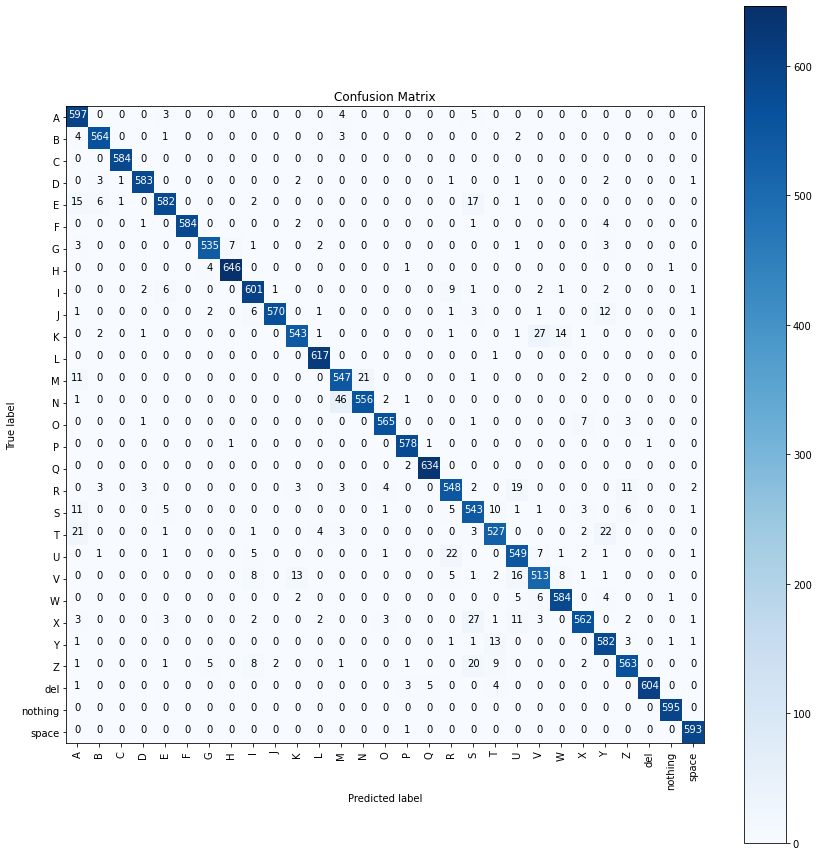

In [ ]:
# Plot the confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize = (12,12))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plt.figure(figsize=(10, 10))
plot_confusion_matrix(confusion_mtx, classes = class_names, title='Confusion Matrix')
plt.show()

AUC for class A: 0.9961
AUC for class B: 0.9993
AUC for class C: 0.9993
AUC for class D: 0.9962
AUC for class E: 0.9902
AUC for class F: 0.9993
AUC for class G: 0.9945
AUC for class H: 0.9991
AUC for class I: 0.9867
AUC for class J: 0.9891
AUC for class K: 0.9875
AUC for class L: 0.9988
AUC for class M: 0.9857
AUC for class N: 0.9948
AUC for class O: 0.9959
AUC for class P: 0.9973
AUC for class Q: 0.9992
AUC for class R: 0.9911
AUC for class S: 0.9882
AUC for class T: 0.9907
AUC for class U: 0.9942
AUC for class V: 0.9837
AUC for class W: 0.9978
AUC for class X: 0.9893
AUC for class Y: 0.9924
AUC for class Z: 0.9921
AUC for class del: 0.9943
AUC for class nothing: 1.0000
AUC for class space: 0.9995


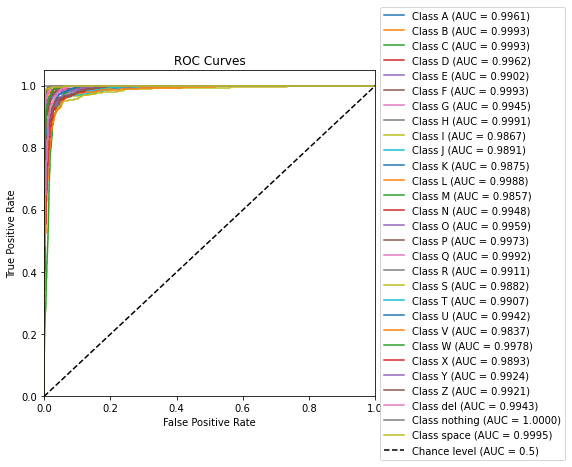

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Calculate the AUC for each class
auc_scores = {}
for i in range(num_classes):
    auc_scores[class_names[i]] = roc_auc_score(y_true == i, y_pred[:, i])

# Print the AUC scores for each class
for class_name, auc_score in auc_scores.items():
    print(f"AUC for class {class_name}: {auc_score:.4f}")

# Plot the ROC curves for each class
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true == i, y_pred[:, i])
    plt.plot(fpr, tpr, label=f"Class {class_names[i]} (AUC = {auc_scores[class_names[i]]:.4f})")

# Plot the chance level
plt.plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')

# Adjust the plot to make space for the legend on the right
plt.subplots_adjust(right=0.7)

# Place the legend to the right of the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

In [ ]:
model.evaluate(train_dataset)


/home/madeng/.local/lib/python3.10/site-packages/keras/src/backend.py:5727: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1633/1633 [==============================] - 375s 229ms/step - loss: 0.3374 - accuracy: 0.9602


[0.33742958307266235, 0.9601576924324036]

In [ ]:
model.evaluate(test_dataset)

543/543 [==============================] - 167s 237ms/step - loss: 0.3405 - accuracy: 0.9588


[0.340498149394989, 0.958832323551178]

In [ ]:
model.evaluate(validation_dataset)

543/543 [==============================] - 169s 254ms/step - loss: 0.3414 - accuracy: 0.9601


[0.3414272964000702, 0.9600598812103271]